[2026-08-04 23:22:29] [info     ] 计算因子，区间：2022-01-01 00:00:00 ~ 2025-12-31 23:59:59
[2026-08-04 23:22:42] [info     ] 读取因子库，区间：2022-01-01 00:00:00 ~ 2025-12-31 23:59:59
[2026-08-04 23:22:43] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-04 23:22:56] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 23:22:56] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 23:22:58] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2022-01-04 至 2024-12-31
[2026-08-04 23:22:58] [info     ] ========== 数据检查 ==========
[2026-08-04 23:22:58] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0006
2024-09-24~2024-10-08,-0.0014

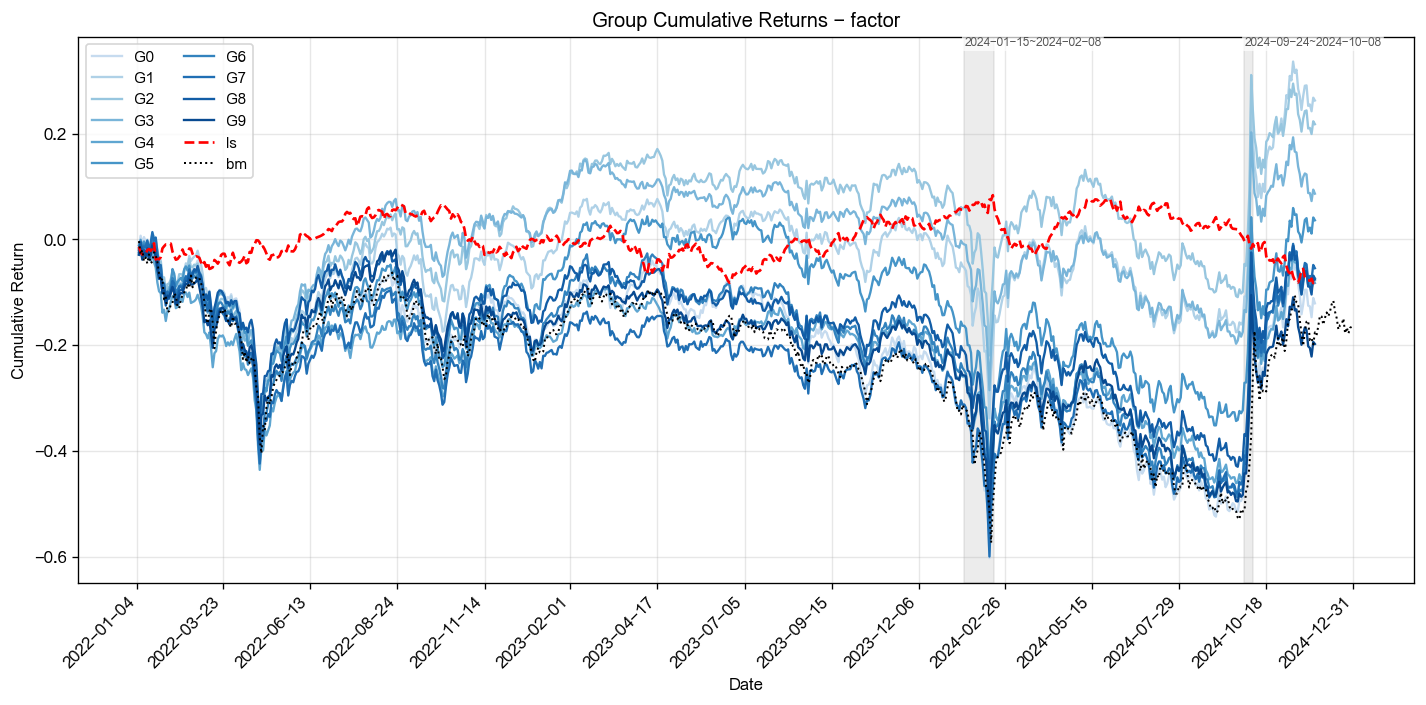
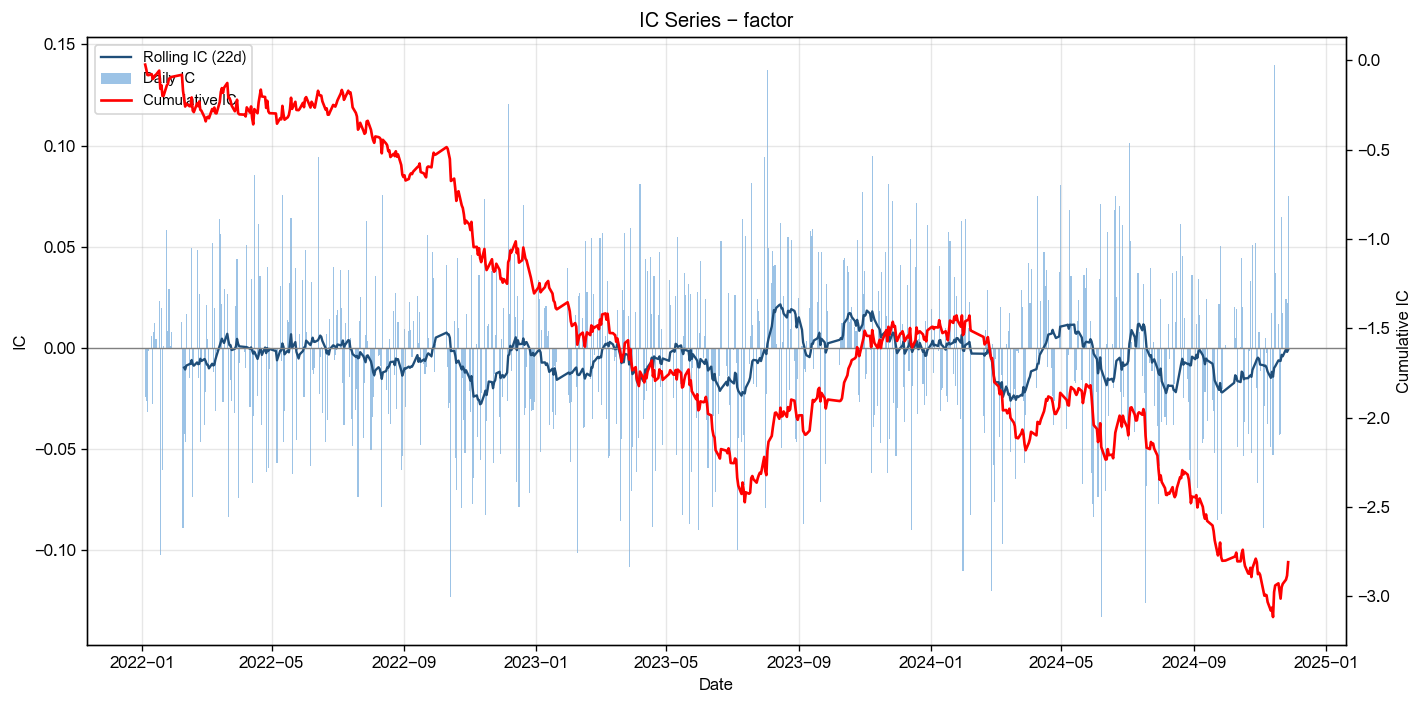
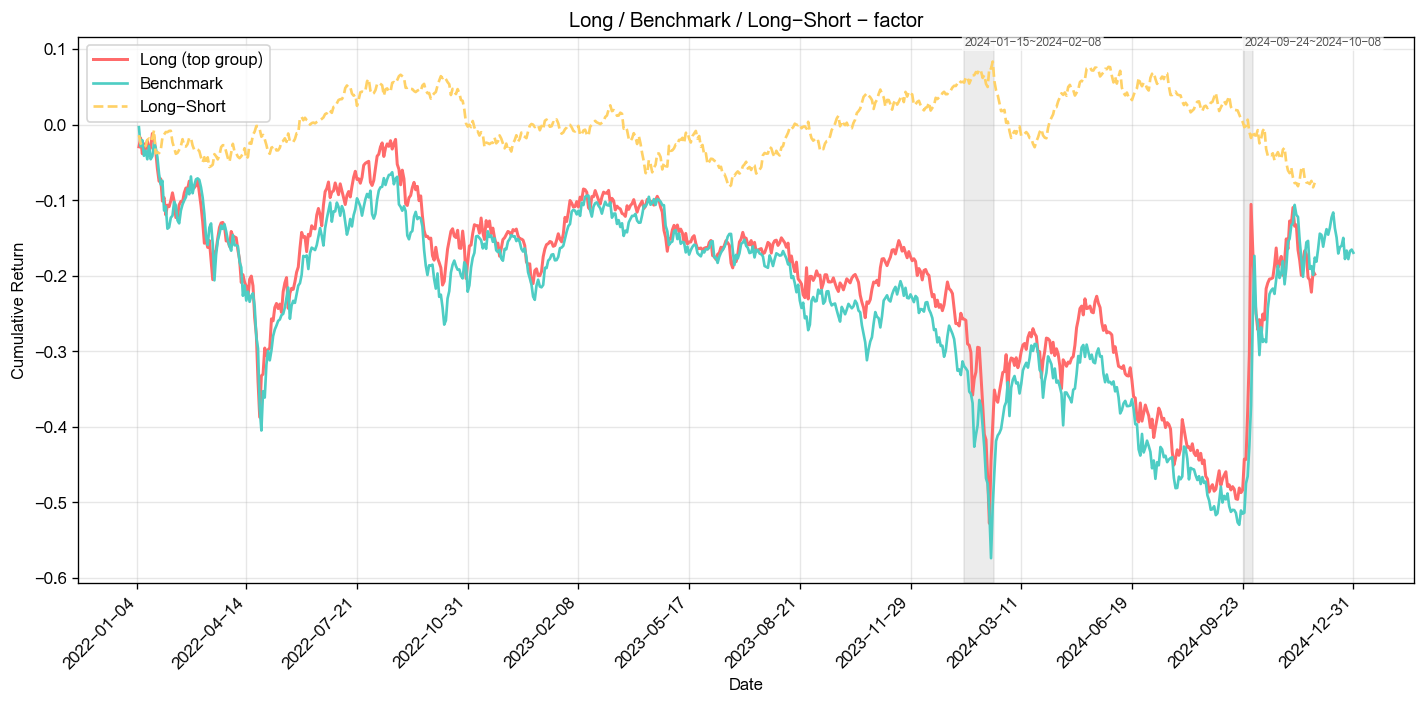
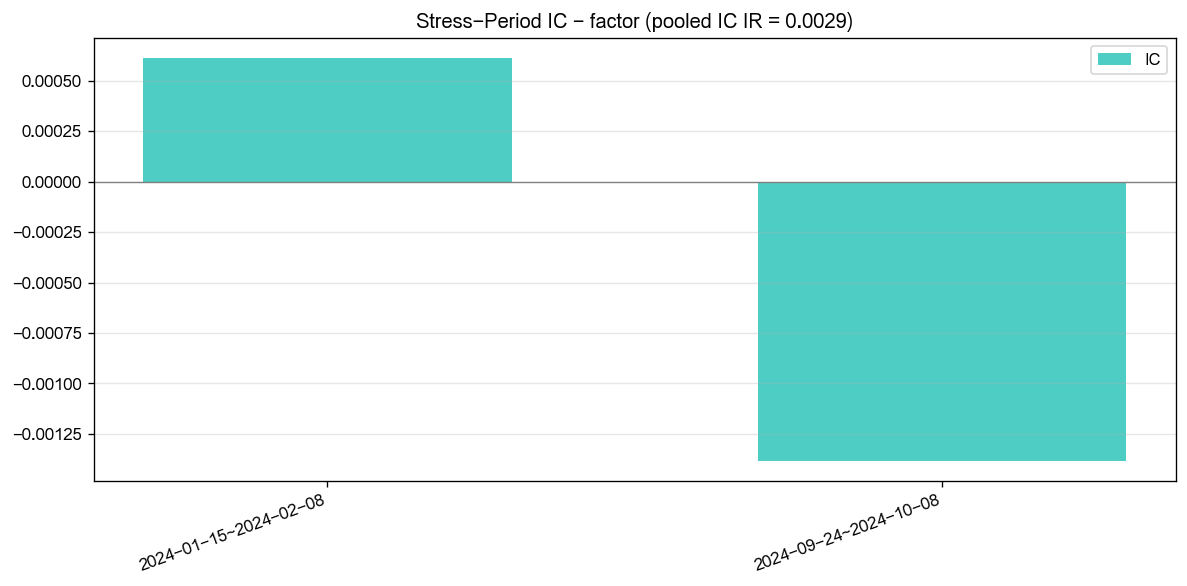
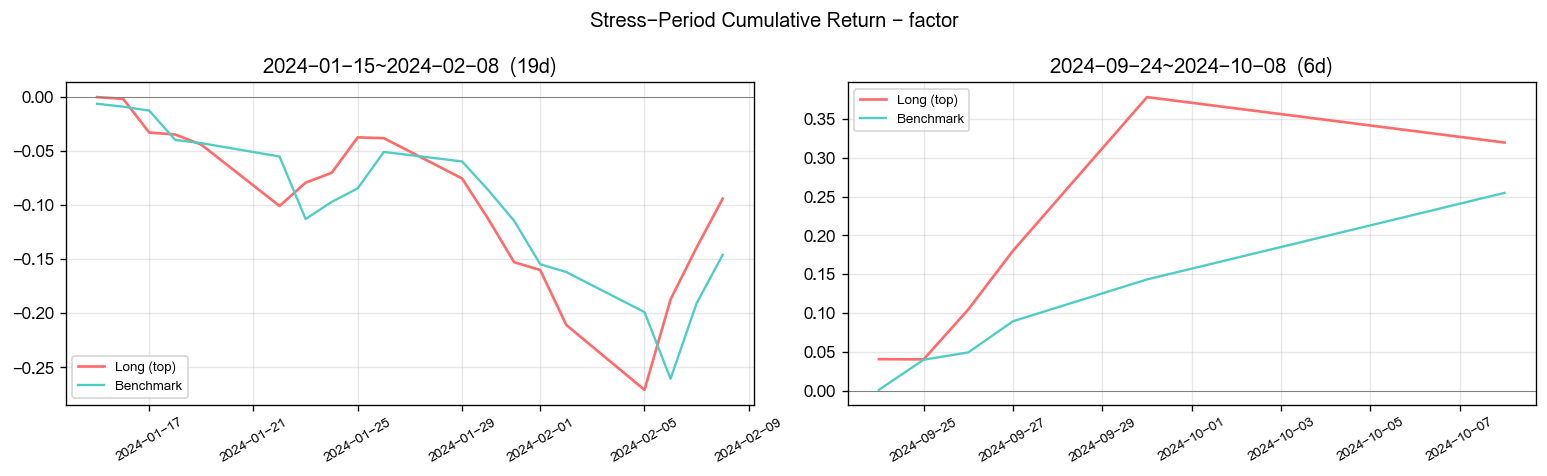

[2026-08-04 23:23:39] [info     ] ========== 因子池回归 ==========
[2026-08-04 23:23:40] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1571 rows=1105750 start_date=2022-01-04
[2026-08-04 23:23:41] [info     ] 获取收益率数据, 耗时: 2.7235 秒
[2026-08-04 23:23:43] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.9401 秒
[2026-08-04 23:23:43] [info     ] 统计 回归结果, 耗时: 0.0985 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,volatility_5,1.5532,0.0159,0.0102,1.0000
2,cci_14,1.3923,0.0256,0.0184,1.0000
3,beta_000300SH_22,1.3710,0.0183,0.0133,0.9706
4,netflow_amount_main,1.3548,0.0216,0.0159,0.9412
5,roe_avg_ttm,1.3466,0.0094,0.0070,0.8529
6,rsi_12,1.3351,0.0328,0.0246,0.9412
7,volume,1.3206,0.0156,0.0118,1.0000
8,net_active_buy_amount_main,1.3180,0.0187,0.0142,0.9412
9,bias_20,1.3170,0.0279,0.0212,0.9412
10,amount,1.3111,0.0237,0.0180,0.9706

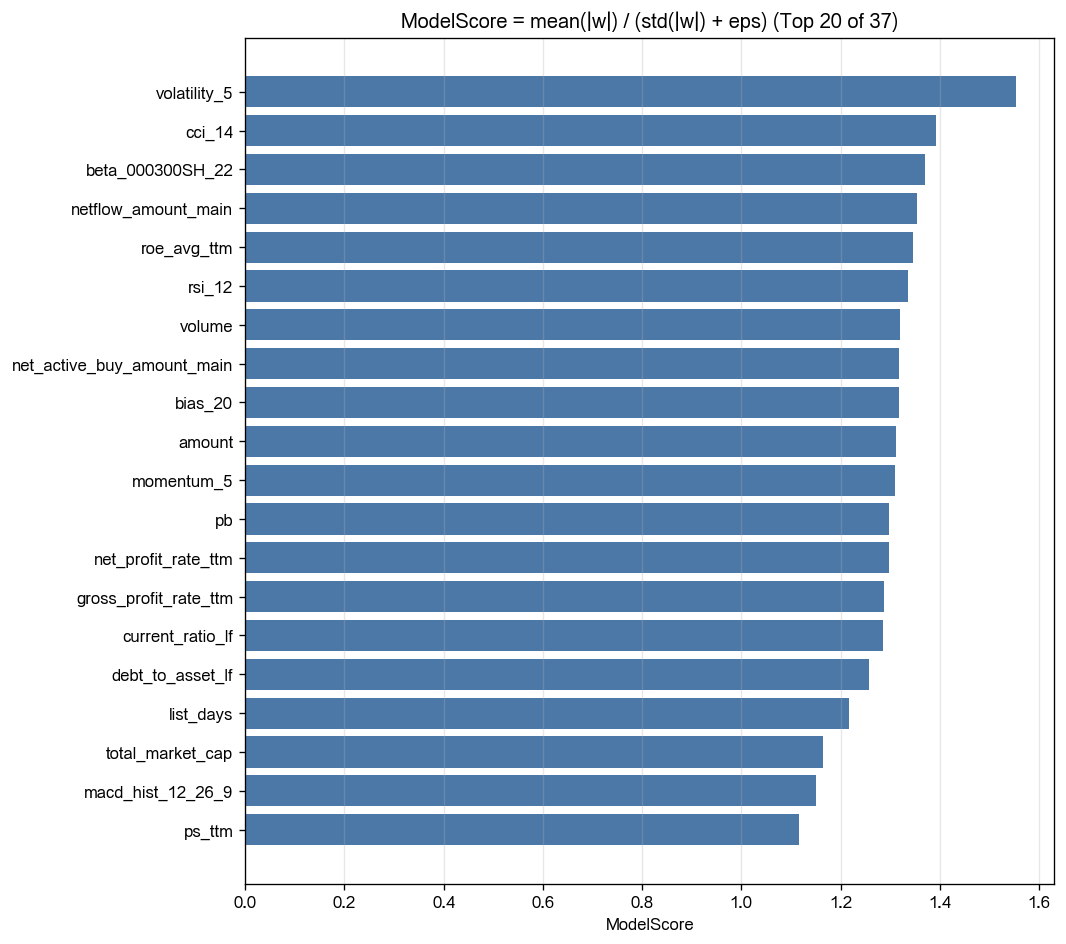
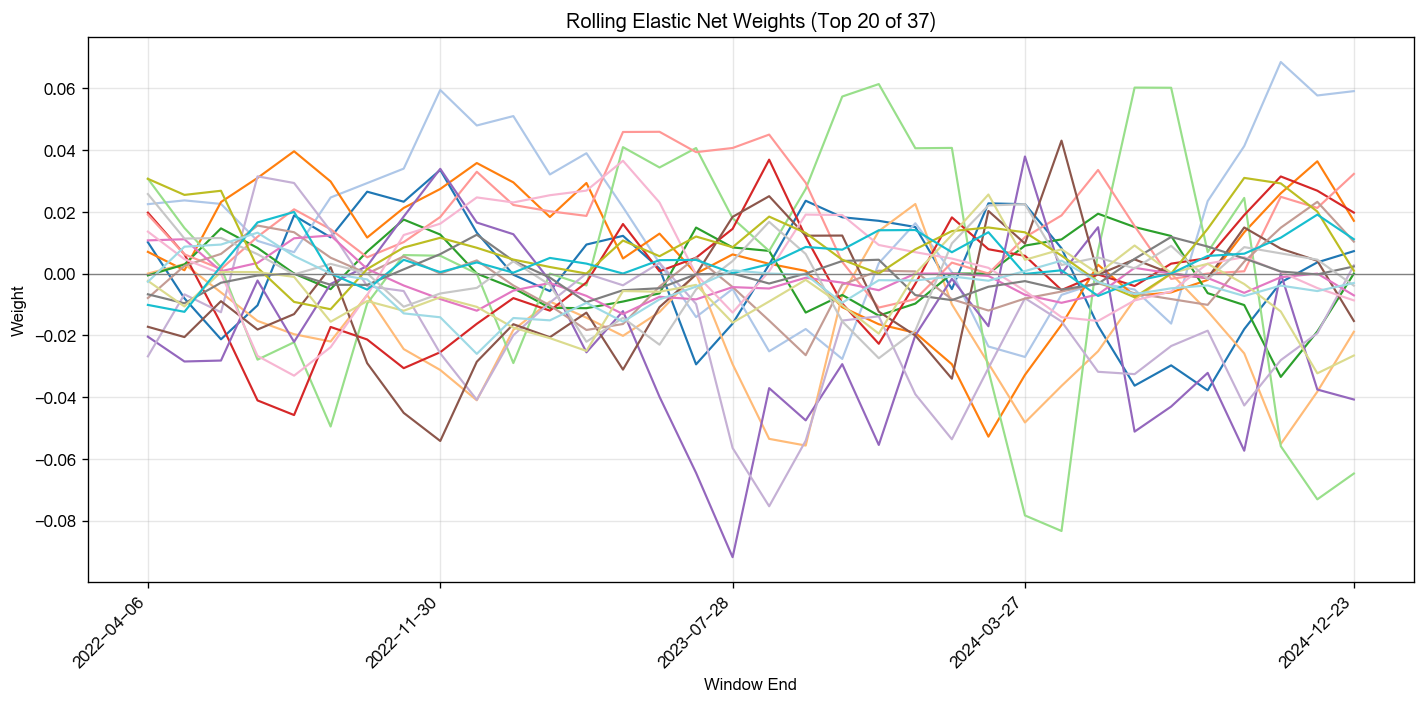
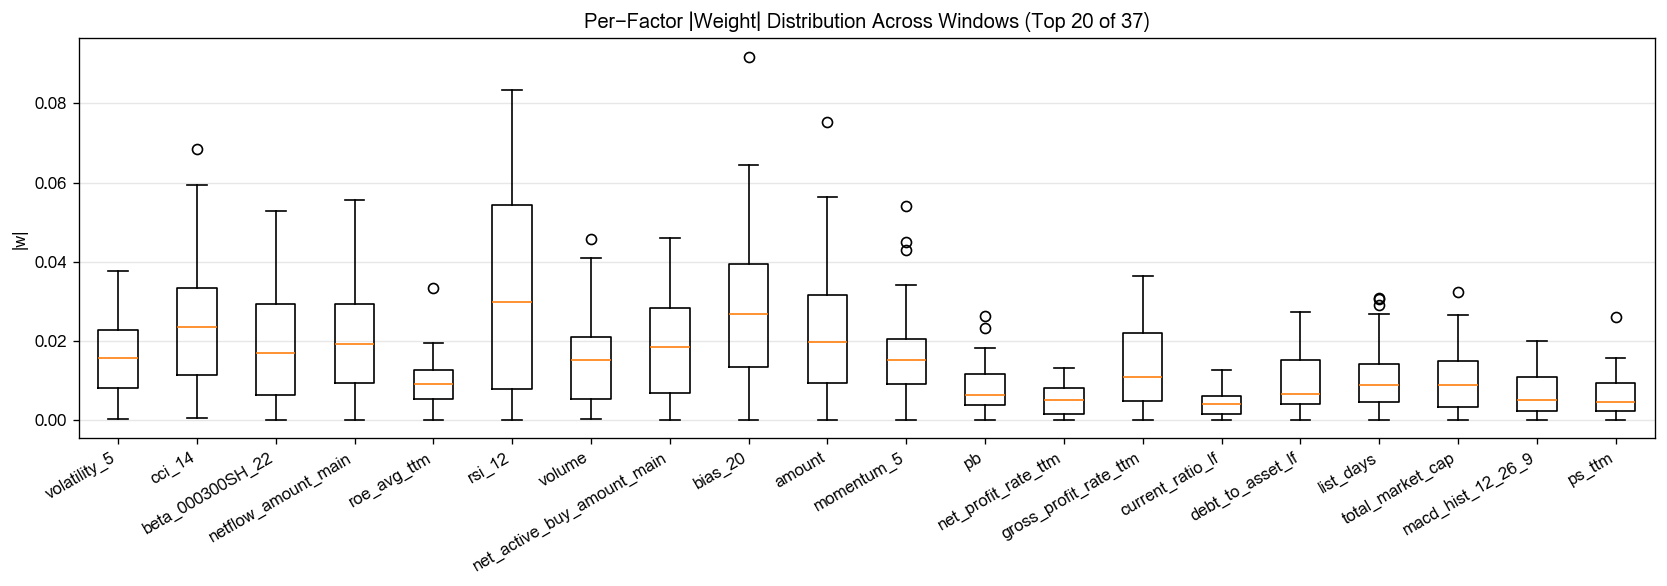
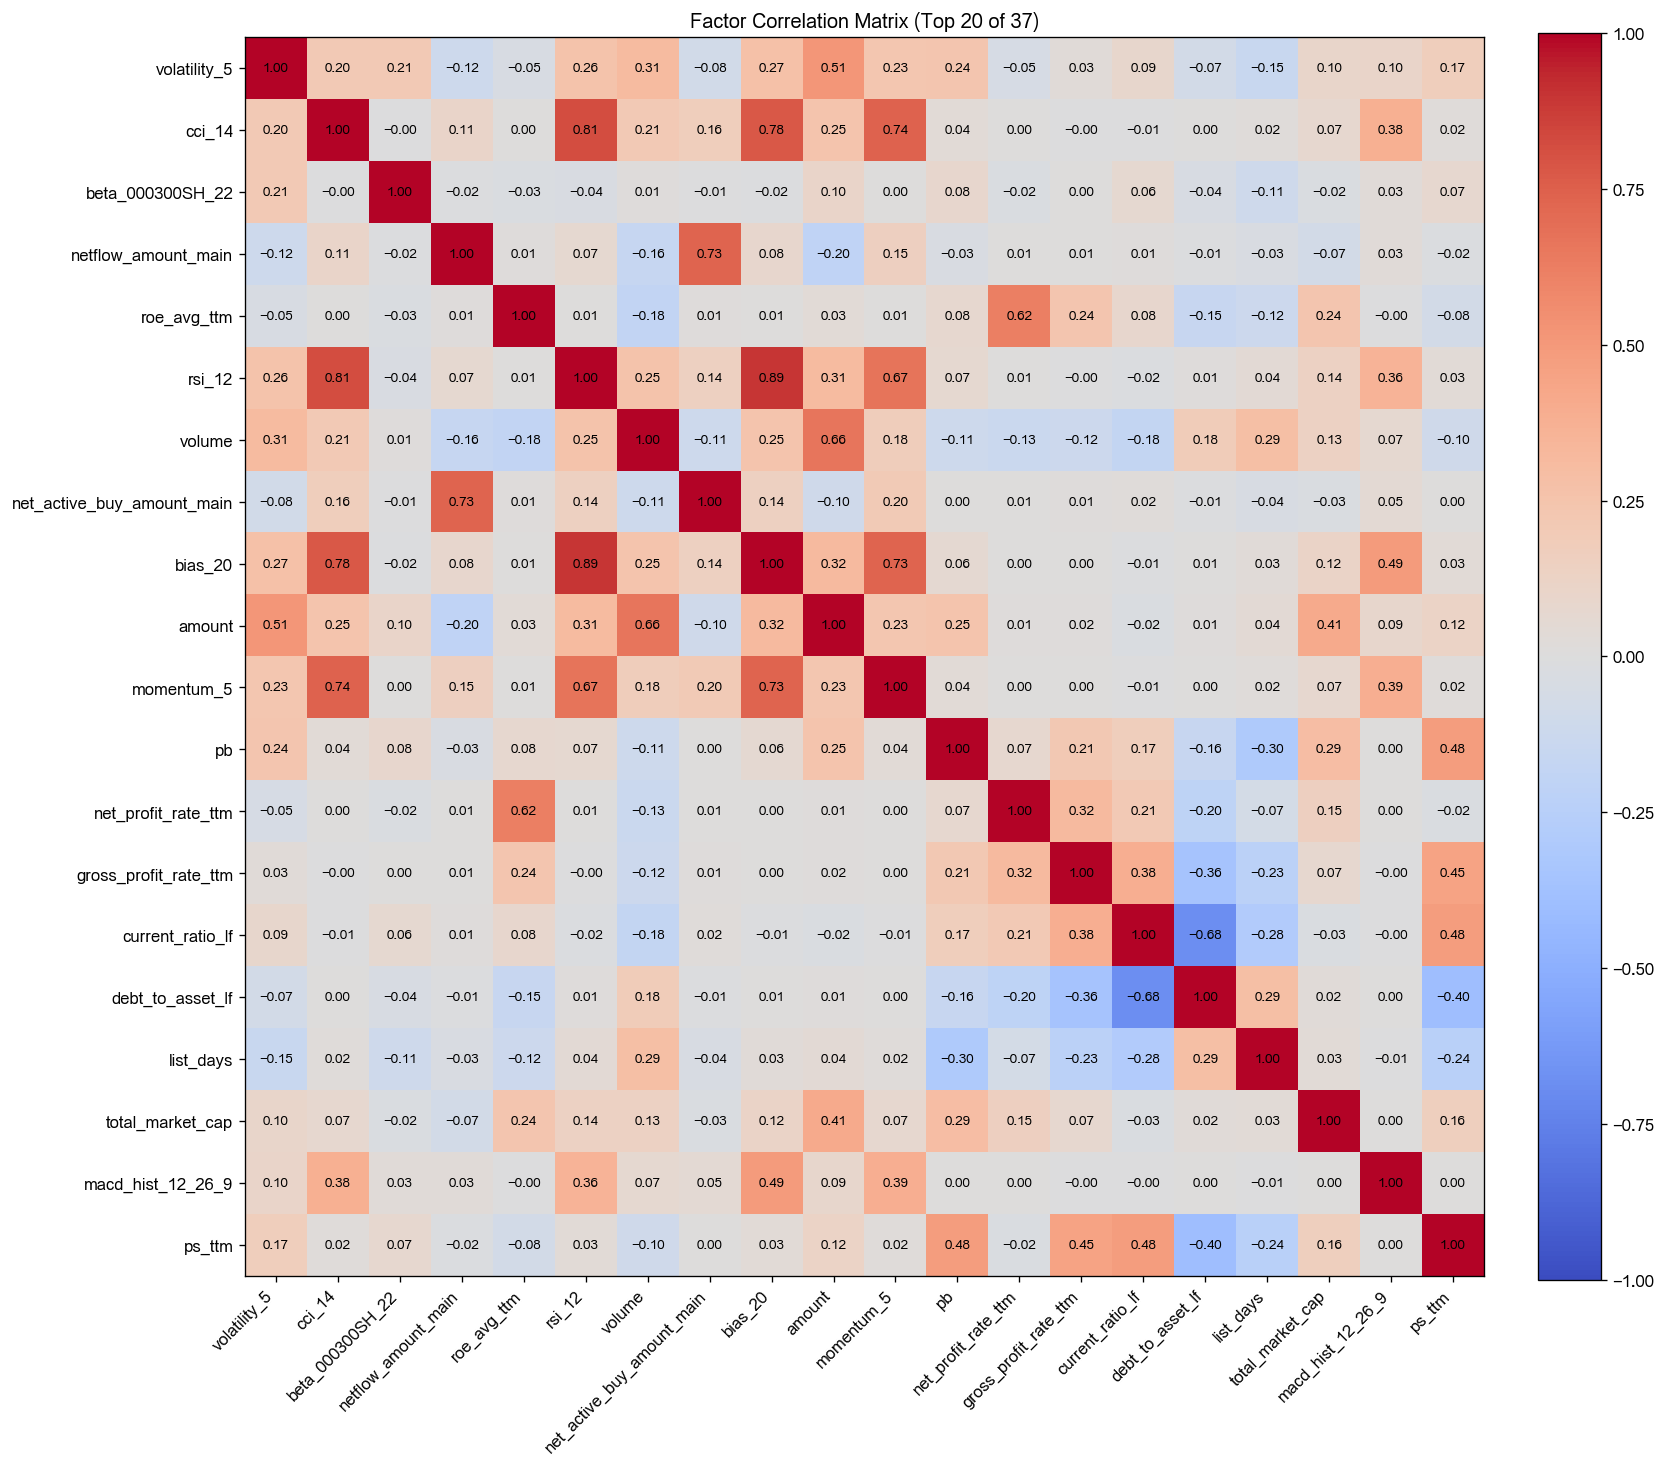

[2026-08-04 23:23:49] [warning  ] 返回的Outputs实例(size=105640316) 大于 64K, 将不会被缓存
[2026-08-04 23:23:49] [info     ] bigalpha_eval.v4 运行完成 [52.871s].


In [3]:
def main(datasources, start_date, end_date):
    """
    因子构建主函数

    因子逻辑 (Factor11 CTS-AUC):
        diff = Amount[14:57-15:00] - Amount[14:54-14:57)
        factor = sign(diff) * ln(|diff|)   # diff=0 时为 0
        （相对原版：原版仅保留 diff>0；平台覆盖度要求下对 diff<=0 做有符号延拓）

    返回:
        pd.DataFrame: ['date', 'instrument', 'factor']，且不含 inf
    """
    import pandas as pd
    import dai

    bar1m = datasources["bar1m"]

    sql = f"""
    WITH cte_bar1m AS (
        SELECT
            date,
            instrument,
            amount,
            strftime(date, '%Y-%m-%d') AS trading_day,
            -- CTS: [14:54, 14:57)
            CASE
                WHEN hour(date) = 14 AND minute(date) BETWEEN 54 AND 56
                THEN amount
                ELSE 0
            END AS cts_amount,
            -- AUC: [14:57, 15:00]
            CASE
                WHEN (hour(date) = 14 AND minute(date) BETWEEN 57 AND 59)
                  OR (hour(date) = 15 AND minute(date) = 0)
                THEN amount
                ELSE 0
            END AS auc_amount
        FROM {bar1m}
        WHERE amount IS NOT NULL AND amount >= 0
    ),
    cte_daily AS (
        SELECT
            trading_day,
            instrument,
            SUM(cts_amount) AS amount_cts,
            SUM(auc_amount) AS amount_auc,
            SUM(auc_amount) - SUM(cts_amount) AS amount_diff,
            CASE
                WHEN SUM(auc_amount) - SUM(cts_amount) > 0
                THEN ln(SUM(auc_amount) - SUM(cts_amount))
                WHEN SUM(auc_amount) - SUM(cts_amount) < 0
                THEN -ln(SUM(cts_amount) - SUM(auc_amount))
                ELSE 0.0
            END AS factor
        FROM cte_bar1m
        GROUP BY instrument, trading_day
        -- 两段窗口至少有一边有成交，避免全 0 噪音
        HAVING SUM(cts_amount) + SUM(auc_amount) > 0
    )
    SELECT
        CAST(trading_day AS DATETIME) AS date,
        instrument,
        factor
    FROM cte_daily
    WHERE factor IS NOT NULL
      AND isfinite(factor)
    """

    df = dai.query(sql, filters={'date': [start_date, end_date]}, compression=True).df()

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={'date': [start_date, end_date]},
    ).df()
    df = pd.merge(df, stk_pool, how='inner', on=['date', 'instrument'])

    return df


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    start_date = '2022-01-01 00:00:00'
    end_date = '2025-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )